# project01 - Concentrated liquidity primer

A minimal walkthrough of the `lp_analysis` core math: how a Uniswap-v3-style
position is sized from quote-asset capital, how token amounts change with
price, and what the resulting MtM value looks like across a price sweep.

**No leverage** is used in this notebook - see *project02* for leveraged
positions and *project03* for full strategy analysis.

In [6]:
from lp_analysis import (
    AssetPair, PriceRange, PoolConfig, LendingPolicy, StrategyConfig,
    open_position, simulate, linear_price_sweep, to_frame, dashboard,
    plot_pnl, plot_composition,
)
import matplotlib.pyplot as plt
import numpy as np

## 1. Configure an ETH/USDC pool

In [7]:
pool = PoolConfig(
    pair=AssetPair(asset0='ETH', asset1='USDC'),
    price_initial=3500.0,
    price_range=PriceRange(lower=3000.0, upper=4000.0),
    fee_tier_pct=0.30,
)
# Lending policy is required by StrategyConfig even at leverage=1 because the
# same package models leveraged positions; an unused-debt policy is harmless.
lending = LendingPolicy(
    collateral_factors={'ETH': 0.80, 'USDC': 0.90},
    liquidation_factors={'ETH': 0.85, 'USDC': 0.95},
)
strategy = StrategyConfig(
    name='ETH/USDC plain LP',
    pool=pool, lending=lending,
    capital_asset1=10_000.0, leverage=1.0,
)
initial = open_position(strategy)
print(f'Liquidity     L = {initial.liquidity:.3f}')
print(f'Initial ETH    = {initial.amount0:.6f}')
print(f'Initial USDC   = {initial.amount1:.2f}')

Liquidity     L = 1218.104
Initial ETH    = 1.329800
Initial USDC   = 5345.70


## 2. Sweep the position across a price range

In [8]:
scenario = linear_price_sweep(strategy, n_points=400)
result = simulate(strategy, scenario)
df = to_frame(result, include_margin=False)
df.head()

step,t_days,price,amount_ETH,amount_USDC,debt_token,debt_amount,debt_value_asset1,position_value_asset1,equity_asset1,asset0_net_value_asset1,asset1_net_value_asset1
i64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64
0,0.0,2400.0,2.979519,0.0,"""""",0.0,0.0,7150.845199,7150.845199,7150.845199,0.0
1,0.0,2406.015038,2.979519,0.0,"""""",0.0,0.0,7168.767117,7168.767117,7168.767117,0.0
2,0.0,2412.030075,2.979519,0.0,"""""",0.0,0.0,7186.689035,7186.689035,7186.689035,0.0
3,0.0,2418.045113,2.979519,0.0,"""""",0.0,0.0,7204.610952,7204.610952,7204.610952,0.0
4,0.0,2424.06015,2.979519,0.0,"""""",0.0,0.0,7222.53287,7222.53287,7222.53287,0.0


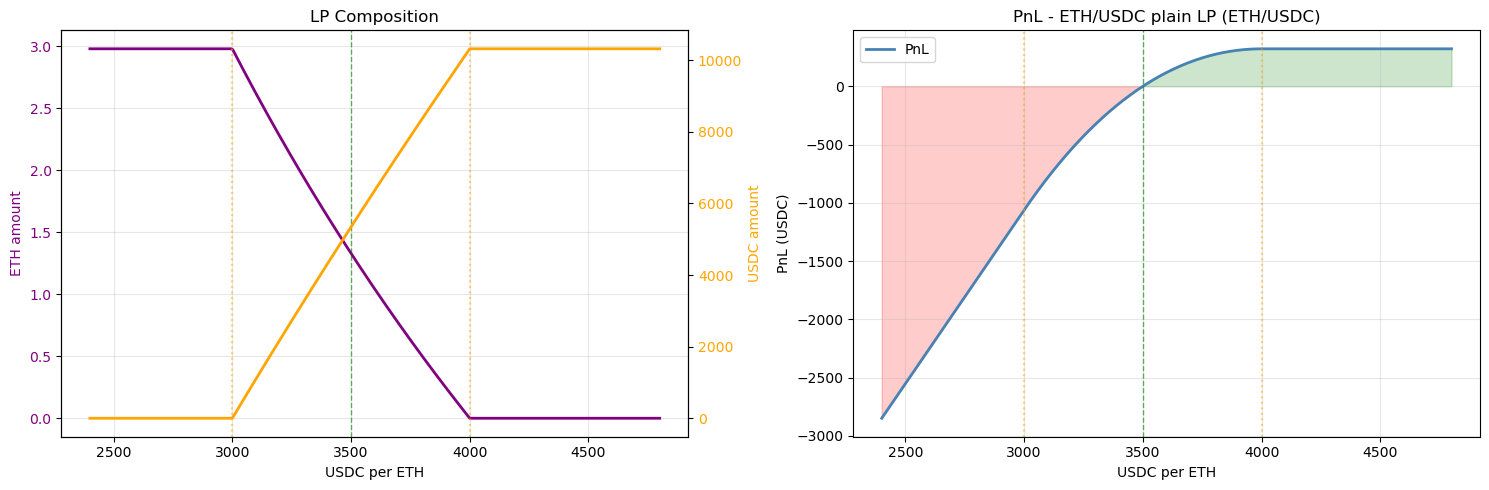

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_composition(result, ax=axes[0])
plot_pnl(result, ax=axes[1])
plt.tight_layout(); plt.show()

## 3. Inspect the polars frame

All per-step quantities are in a tidy frame ready for polars-native
filtering, joins, group-by, or export.

In [10]:
df.select(['step', 'price', 'amount_ETH', 'amount_USDC',
           'position_value_asset1', 'equity_asset1']).describe()

statistic,step,price,amount_ETH,amount_USDC,position_value_asset1,equity_asset1
str,f64,f64,f64,f64,f64,f64
"""count""",400.0,400.0,400.0,400.0,400.0,400.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",199.5,3600.0,1.321464,5641.00563,9564.950151,9564.950151
"""std""",115.614301,695.424369,1.258017,4366.945827,976.281403,976.281403
"""min""",0.0,2400.0,0.0,0.0,7150.845199,7150.845199
"""25%""",100.0,3001.503759,0.0,16.719282,8943.032788,8943.032788
"""50%""",200.0,3603.007519,1.050303,6398.457788,10121.600027,10121.600027
"""75%""",299.0,4198.496241,2.973947,10321.356002,10321.356002,10321.356002
"""max""",399.0,4800.0,2.979519,10321.356002,10321.356002,10321.356002
